In [255]:
%cd /opt/tiger/samantha

/opt/tiger/samantha


In [256]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [251]:
from samantha.dataio.data_bucket import data_bucket
from recipes.mi1.data_enriched.reader import IndexReader

In [14]:
url2index = data_bucket(
    "data/music/billboard_hot200_v2/24000hz/train/20231026_genre/url2index.txt"
)
reader = IndexReader(url2index)
min_duration = 2
max_duration = 30

Loaded 309 index urls


100%|██████████| 309/309 [07:03<00:00,  1.37s/it]


In [240]:
reader.indexes.to_pickle("billboard_200_train_index.p")

<Axes: title={'center': 'Top-50 (discogs?) genres in Billboard Lyric'}>

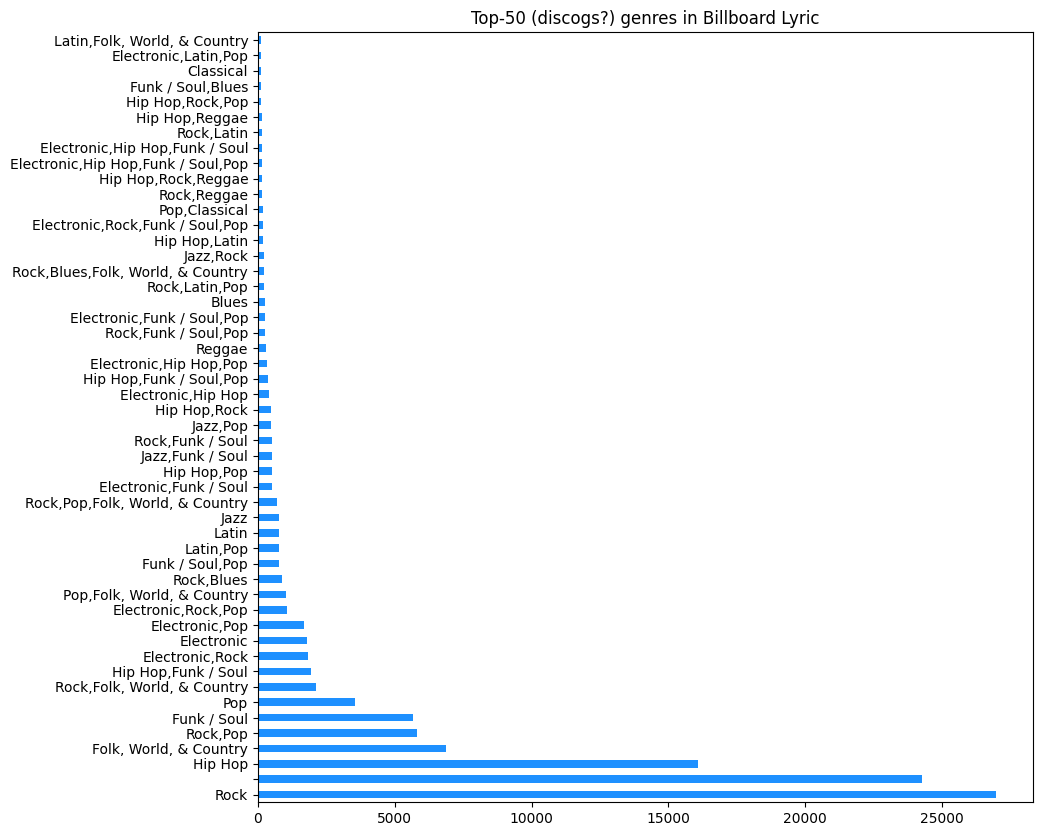

In [402]:
reader.indexes.genre.value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 (discogs?) genres in Billboard Lyric", color="dodgerblue")

<Axes: title={'center': 'Top-50 (discogs?) styles in Billboard Lyric'}>

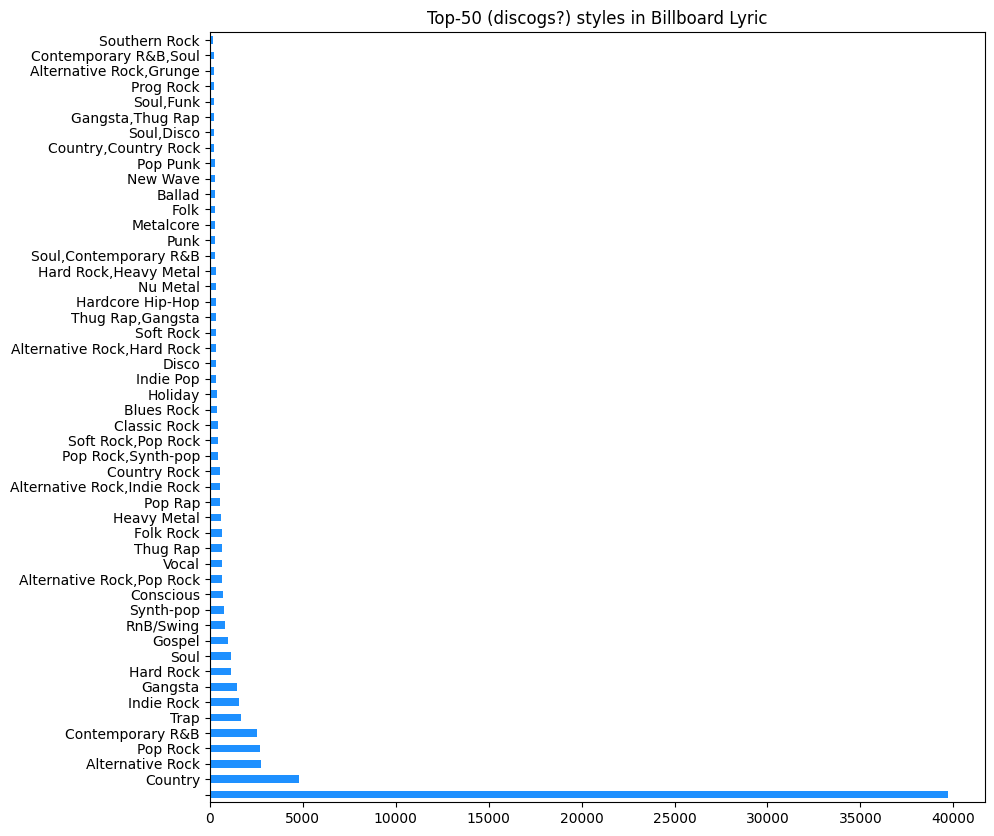

In [406]:
reader.indexes["style"].value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 (discogs?) styles in Billboard Lyric", color="dodgerblue")

In [18]:
from typing import Dict, List

def select_tag_metadata_from_timestamps(index_data, start: int, end: int) -> Dict[str, List[str]]:
    mir_tags = index_data.get("tags")
    genres = []
    vocals = []
    
    if len(mir_tags["starts"]):
        def closest_time(times, t):
            difference = lambda times: abs(times - t)
            return min(times, key=difference)

        mir_start = closest_time(mir_tags["starts"], start)
        mir_end = closest_time(mir_tags["ends"], end)
        mir_start_idx = mir_tags["starts"].index(mir_start)
        mir_end_idx = mir_tags["ends"].index(mir_end)

        for idx in range(mir_start_idx, mir_end_idx + 1):
            genres.extend(mir_tags["genre"][idx])
            vocals.extend(mir_tags["vocal"][idx])
    return dict(genres=genres, vocals=vocals)

In [19]:
from collections import Counter

def most_common_genre(mcc_genres: dict):
    c = Counter()
    for idx, (start, end) in enumerate(zip(mcc_genres["starts"], mcc_genres["ends"])):
        genre_text = " ".join(sorted(mcc_genres["genre"][idx]))
        duration = end-start
        c[genre_text] += duration
        
    genre_name, _ = c.most_common(1)[0]
    return genre_name


In [379]:
from recipes.datasets.billboard.billboard import BillboardLyricsTransform, LyricPhonemeTokenizer

lyric_tokenizer = LyricPhonemeTokenizer()

def billboard_index_to_segments(index: dict, min_duration, max_duration) -> List[dict]:
    # style_text = BillboardLyricsTransform.billboard_to_compat_style_text(test_index)
    segments = BillboardLyricsTransform.billboard_to_compat_lyrics(index, min_duration, max_duration)
    
    filtered_segments = []
    for segment in segments:
        duration = segment.end - segment.start
        if duration < min_duration or duration > max_duration:
            continue
        
        index_metadata = select_tag_metadata_from_timestamps(index, segment.start, segment.end)
        
        # lyrics_dict = lyric_tokenizer(segment.text)
        # normalized_text = lyrics_dict["normalized_text"][0]
        # tokens = lyrics_dict["tokens"][0]
        
        # if len(tokens) > 400: # TODO
        #     continue
        
        i = {}
        i["segment_vocal"] = index_metadata["vocals"]
        i["segment_genres"] = index_metadata["genres"]
        i["start"] = segment.start
        i["end"] = segment.end
        i["duration"] = duration
        i["text"] = segment.text
        i["confidence"] = segment.confidence
        i["key"] = index["key"]
        # i["normalized_text"] = normalized_text
        # i["tokens"] = tokens.numpy()
        filtered_segments.append(i)
    return filtered_segments

## Segments

In [380]:
import pandas as pd
from tqdm import tqdm

reader.indexes["n_segments"] = 0

segment_index = []
for idx, row in tqdm(reader.indexes.iterrows(), total=len(reader.indexes)):        
    index = row.to_dict()
    segments = billboard_index_to_segments(index, min_duration, max_duration)
    
    reader.indexes.loc[idx, "n_segments"] = len(segments)
    segment_index.extend(segments)
    
segment_index = pd.DataFrame(segment_index)

100%|██████████| 117467/117467 [00:27<00:00, 4257.11it/s]


## Phoneme Tokens

In [205]:
import numpy as np
phoneme_tokens = np.vstack(segment_index.tokens)

pad_token_id = 0
token_length = np.argmax(phoneme_tokens == pad_token_id, axis=1)

In [206]:
segment_index["token_length"] = token_length

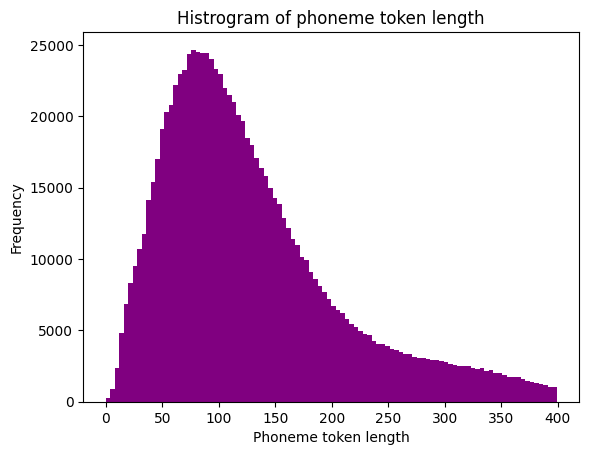

In [207]:
ax = segment_index["token_length"].plot.hist(bins=100, color="purple", title="Histrogram of phoneme token length")
ax.set_xlabel("Phoneme token length")
plt.show()

In [209]:
tokens, counts = np.unique(phoneme_tokens[phoneme_tokens != pad_token_id], return_counts=True)

In [210]:

vocab = tokenizer.tokenizer.get_vocab()
idx2vocab = {v: k for k, v in vocab.items()}

tokens, counts = map(list, zip(*sorted(zip(tokens, counts), key=lambda x: x[1], reverse=True)))

table = []
for t, c in zip(tokens, counts):
    table.append([t, idx2vocab[t], c])
    
    
from IPython.display import display, HTML
table = pd.DataFrame(table, columns=["token_id", "token", "frequency"])
display(HTML(table.to_html()))
table.to_csv("billboard_train_token_frequency.csv")

,token_id,token,frequency
0,3,<unk>,28174018
1,4,n,6100991
2,6,t,6016346
3,17,ɪ,5052304
4,392,<n>,3835054
5,12,d,3668072
6,5,s,3585947
7,8,l,3577386
8,13,m,3244646
9,37,aɪ,3051971


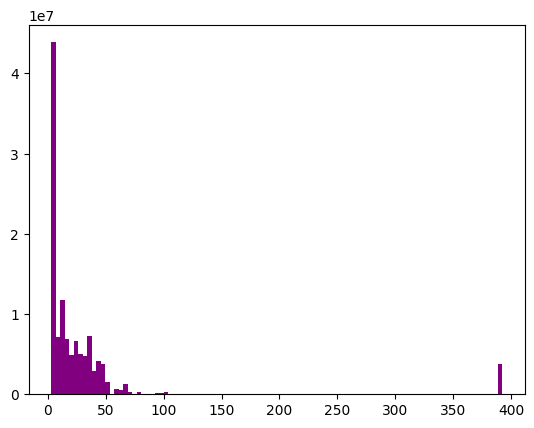

In [163]:
plt.hist(phoneme_tokens[phoneme_tokens != pad_token_id], color="purple", bins=100)
plt.show()

Text(0.5, 0, 'lyric confidence value')

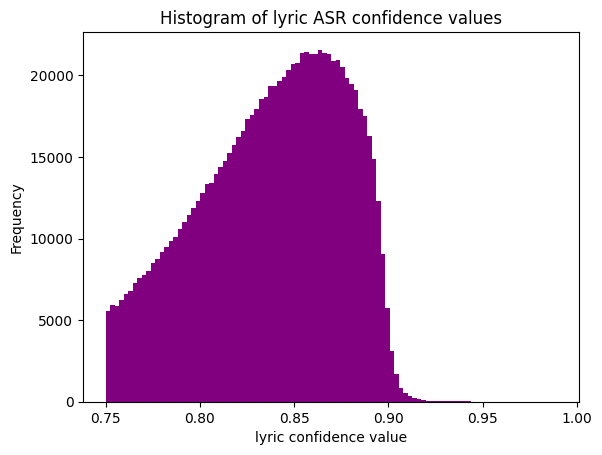

In [381]:
import matplotlib.pyplot as plt

ax = segment_index.confidence.plot.hist(bins=100, title="Histogram of lyric ASR confidence values", color="purple")
ax.set_xlabel("lyric confidence value")

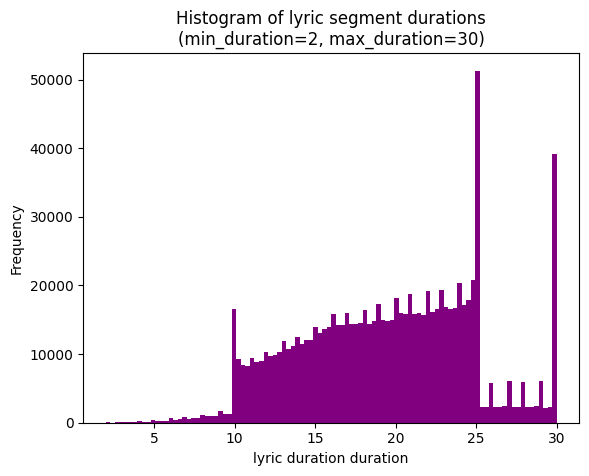

In [382]:
ax = segment_index.duration.plot.hist(bins=100, title=f"Histogram of lyric segment durations\n(min_duration={min_duration}, max_duration={max_duration})", color="purple")
ax.set_xlabel("lyric duration duration")
plt.show()

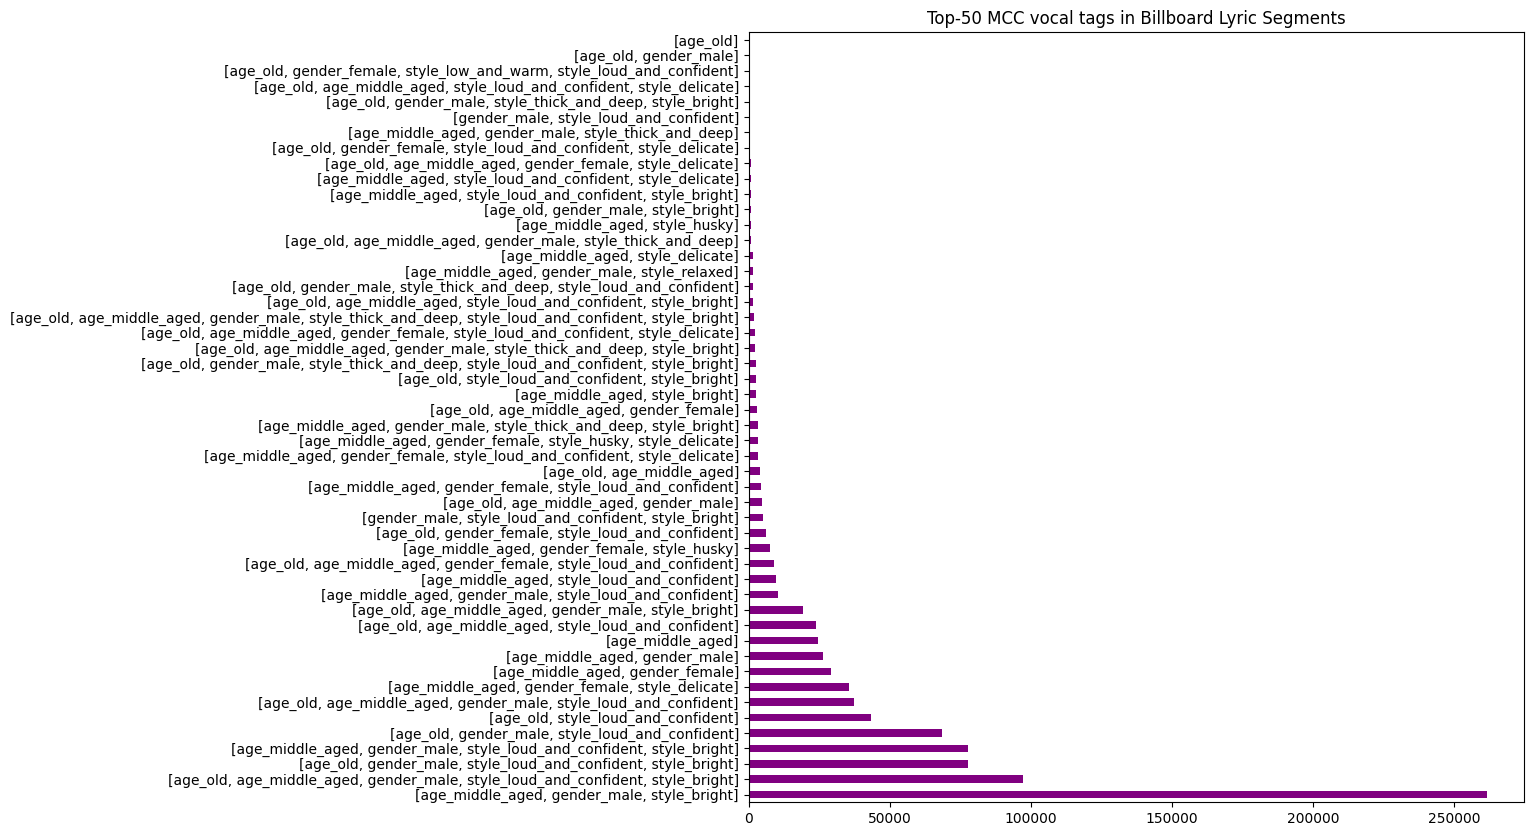

In [383]:
segment_index.segment_vocal.value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 MCC vocal tags in Billboard Lyric Segments", color="purple")
plt.show()

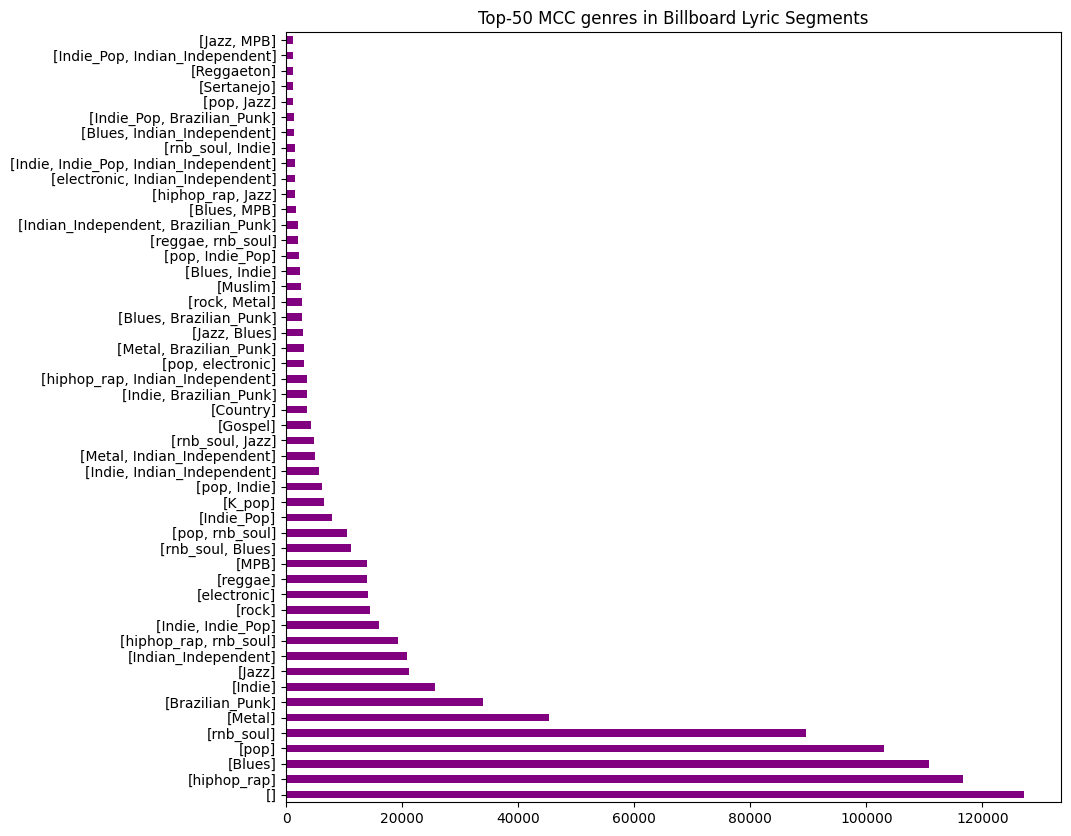

In [384]:
segment_index.segment_genres.value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 MCC genres in Billboard Lyric Segments", color="purple")
plt.show()

## Discogs Genre

In [407]:
discogs_df = pd.read_pickle("billboard_200_train_index.p.discogs")
discogs_df.columns = ["discogs_" + c for c in discogs_df.columns]

In [413]:
# Merge tables
reader.indexes["spotify_album_id"] = reader.indexes.metadata.apply(lambda r: r["spotify_album_id"])
merged_indexes = pd.merge(reader.indexes, discogs_df, left_on="spotify_album_id", right_on="discogs_spotify_album_id")

print("Missing", len(reader.indexes) - len(merged_indexes), "songs")

Missing 8183 songs


<Axes: title={'center': 'Top-50 artists in Billboard Lyric Segments'}>

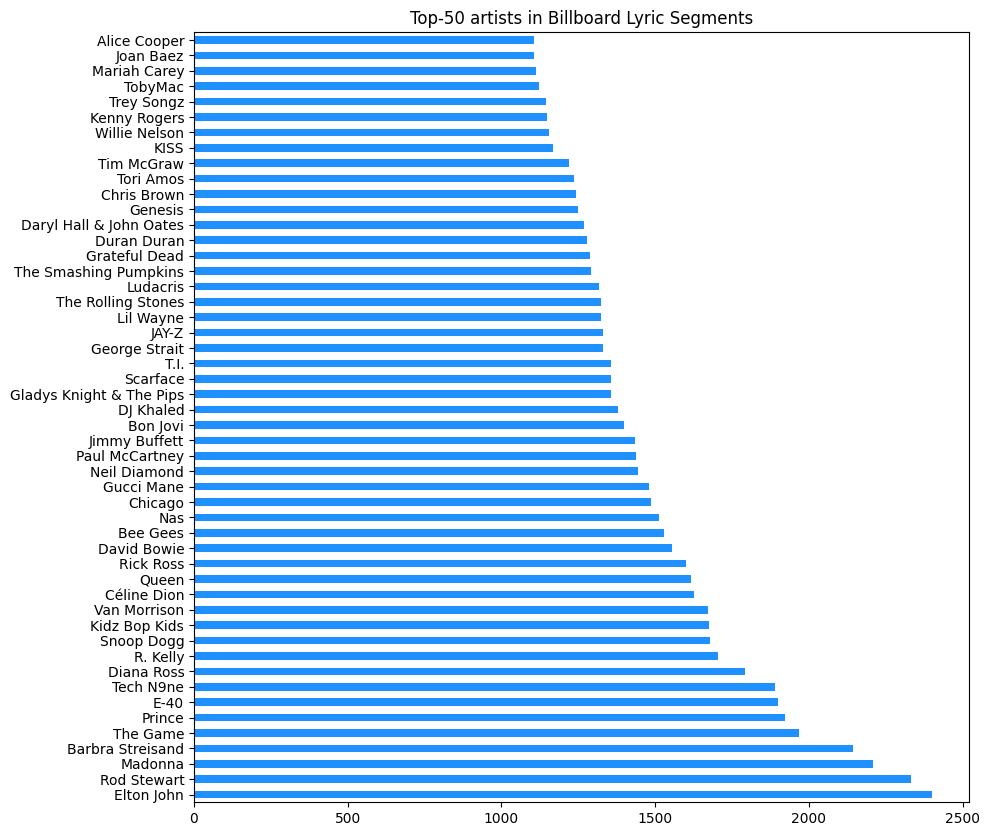

In [426]:
# segment_index.segment_genres.value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 MCC genres in Billboard Lyric Segments", color="purple")

merged_segments = merged_indexes.merge(segment_index, left_on="key", right_on="key")
merged_segments["spotify_primary_artist_name"] = merged_segments.metadata.apply(lambda r: r["spotify_primary_artist_name"])

top_artists = merged_segments.spotify_primary_artist_name.value_counts()

top_artists[:50].plot.barh(figsize=(10,10), title="Top-50 artists in Billboard Lyric Segments", color="dodgerblue")

<Axes: title={'center': 'Top-50 Discogs genres in Billboard Lyric Segments'}>

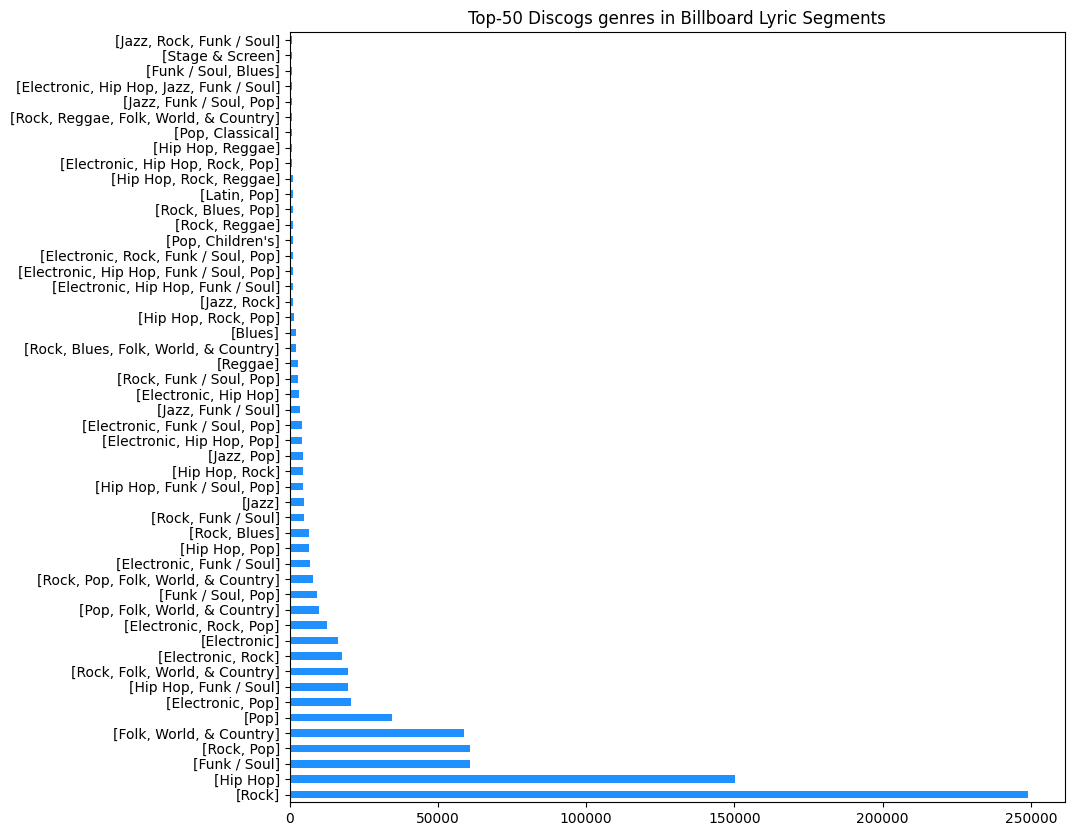

In [441]:
merged_segments.discogs_genres.value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 Discogs genres in Billboard Lyric Segments", color="dodgerblue")

<Axes: title={'center': 'Top-50 Discogs styles in Billboard Lyric Segments'}>

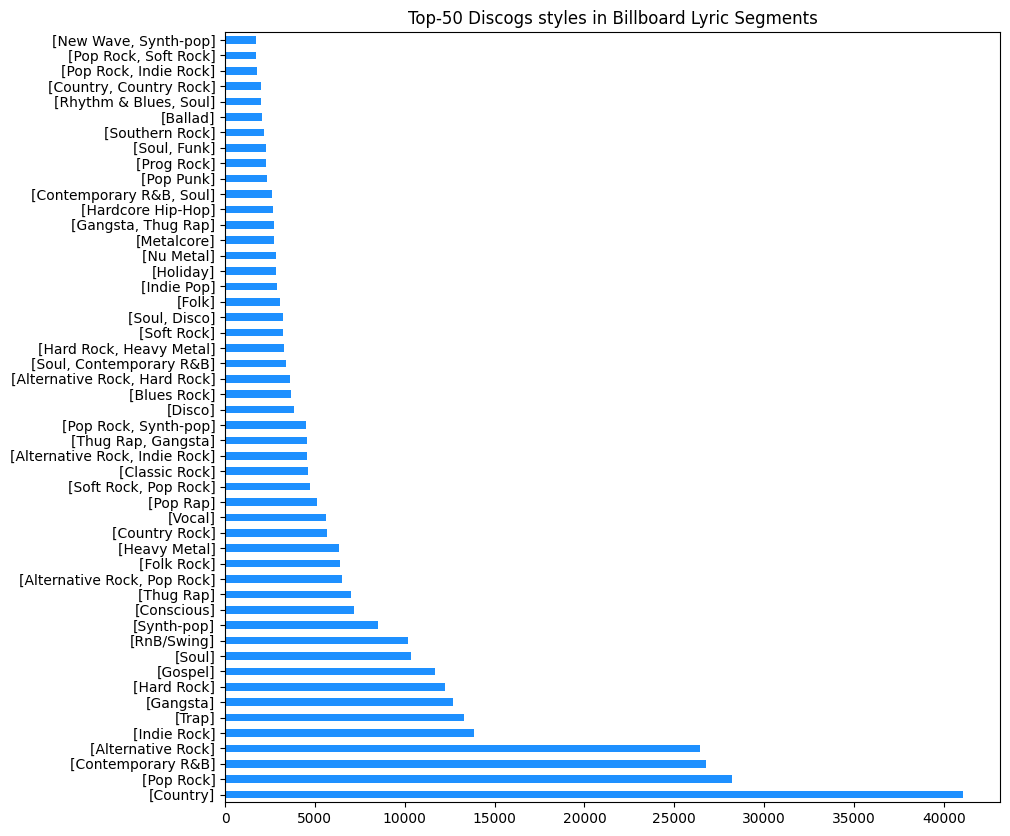

In [442]:
merged_segments.discogs_styles.value_counts()[:50].plot.barh(figsize=(10,10), title="Top-50 Discogs styles in Billboard Lyric Segments", color="dodgerblue")

In [427]:
merged_segments[merged_segments.spotify_primary_artist_name == top_artists.index[0]].discogs_styles.value_counts()

[Pop Rock]                                                                            818
[Pop Rock, Classic Rock]                                                              189
[Pop Rock, Ballad]                                                                    186
[Country Rock, Pop Rock]                                                              181
[Country Rock, Pop Rock, Rock & Roll, Swing, Rhythm & Blues, Glam, Gospel, Ballad]    142
[Soft Rock]                                                                           121
[Hard Rock, Pop Rock, Funk, Glam]                                                      89
[Pop Rock, Soft Rock, Ballad]                                                          81
[Blues Rock, Country Rock, Rock & Roll]                                                77
[Disco, Pop Rock]                                                                      76
[Soft Rock, Pop Rock]                                                                  16
Name: disc

In [438]:
merged_segments["preview_audio_url"] = merged_segments.metadata.apply(lambda r: r["spotify_track_preview_url"])


for i in range(0, 10000, 500):
    row = merged_segments.iloc[i]
    print(row["segment_genres"], row["discogs_genres"], row["preview_audio_url"])

['Gospel'] ['Rock', 'Pop'] https://p.scdn.co/mp3-preview/3b803d7580032092375863d2bf291a906749f3d8?cid=d8a5ed958d274c2e8ee717e6a4b0971d
[] ['Rock', 'Pop'] https://p.scdn.co/mp3-preview/714c23186945f5f3699720b2aff5e4516efc1d40?cid=d8a5ed958d274c2e8ee717e6a4b0971d
['Indie', 'Indie_Pop'] ['Electronic', 'Rock', 'Pop'] https://p.scdn.co/mp3-preview/1a4886f90f341cc1b6001f691c17aaee2d397db3?cid=d8a5ed958d274c2e8ee717e6a4b0971d
['Indian_Independent'] ['Rock'] https://p.scdn.co/mp3-preview/21b45ca6a4cbd27348e5732ecc7e82a80c93854d?cid=d8a5ed958d274c2e8ee717e6a4b0971d
[] ['Electronic', 'Rock', 'Pop'] https://p.scdn.co/mp3-preview/c196eb893ea743c927ac9d11a8179847da7bff47?cid=d8a5ed958d274c2e8ee717e6a4b0971d
['Metal'] ['Rock'] https://p.scdn.co/mp3-preview/a8c03349868e1d2915e2e61a90fd32c05d6123a3?cid=d8a5ed958d274c2e8ee717e6a4b0971d
['hiphop_rap'] ['Hip Hop', 'Funk / Soul'] https://p.scdn.co/mp3-preview/d81c7b3f4515c678038e2fe64073e05d0b470a9f?cid=d8a5ed958d274c2e8ee717e6a4b0971d
['rock'] ['Rock', '

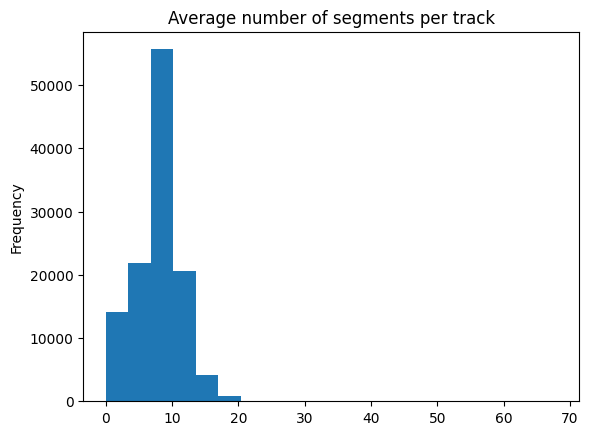

In [40]:
reader.indexes.n_segments.plot(kind="hist", bins=20, title="Average number of segments per track")
plt.show()